# First parameter estimation

## Unit system

The model flux equation is:

    v [mmol/(gDCW*h)] = kcat [mmol/(mg_prot*h)] * e [mg_prot/gDCW] * kappa * gamma

Enzyme concentrations (Data/important_proteins.csv) are in mg_prot/gDCW, so kcat
must be in mmol/(mg_prot*h). Table IV reports kcat both in s^-1 and converted:

    kcat [mmol/(mg_prot*h)] = kcat_s [1/s] * 3600 [s/h] / MW [g/mol]

(1/s * s/h / (g/mol) = mol/(g*h) = mmol/(mg*h), numerically identical.)
Example: FBA kcat = 10.33 s^-1, MW = 39147 g/mol -> 0.95 mmol/(mg_prot*h).
v_max_1 (PTS) is in mmol/(gDCW*h) directly (empirical formulation).

## Parameter split: 

Fixed parameters:
- Kg6p
- kf6p
- kg6p
- kfbp
- kadp
- kg3p
- kdhap
- kdhap
- kg3p
- kg3p
- kpi
- knad
- knadh
- kpgp
- kadp
- k2pg
- kpep



In [5]:
import sys
import os
import json
import pickle
import warnings
import datetime

import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt

# warnings.filterwarnings("ignore")

_REPO_ROOT = os.path.abspath(os.path.dirname("__file__"))
sys.path.insert(0, os.path.join(_REPO_ROOT, "src"))

from kinetics_noor import ALL_PARAMS
from param_estimation_parmest import (
    GlycolysisParameterEstimator,
    available_conditions,
    check_solver,
    THETA_BOUNDS,
    ALL_PARAMS as ALL_PARAMS_est,
)

# Tunable globals
SEED = 0
# Metabolite-bounds modeling knob: log-space mean +/- N_STD*std (see
# utils.metabolite_bounds). Used by BOTH the fit and the sensitivity.
N_STD = 3
SIGMA_LOG10 = 0.5

_REPO_ROOT = os.path.abspath(".")  # notebook runs from repo root
RESULTS_DIR = os.path.join(_REPO_ROOT, "results", "second_estimation")
FIRST_ESTIMATION_DIR = os.path.join(_REPO_ROOT, "results", "first_estimation")
os.makedirs(RESULTS_DIR, exist_ok=True)

# All 22 experimental conditions from the Ishii dataset.
# To use a subset for faster prototyping, replace with e.g.:
#   CONDITIONS = ["KO02", "KO03", "KO05"]
# Deterministic: all conditions, sorted -- shared with fixed_estimation so the
# sensitivity analysis is on the same footing (order-independent for the fit).
CONDITIONS = sorted(available_conditions())
print("ALL_PARAMS count:", len(ALL_PARAMS))
print("CONDITIONS (%d):" % len(CONDITIONS), CONDITIONS)

ALL_PARAMS count: 37
CONDITIONS (22): ['KO02', 'KO03', 'KO04', 'KO05', 'KO07', 'KO08', 'KO10', 'KO11', 'KO12', 'KO13', 'KO14', 'KO15', 'KO16', 'KO17', 'KO18', 'KO19', 'KO20', 'KO21', 'KO22', 'KO23', 'KO24', 'RF03']


## Parameter catalogue and Bar-Even sampler


Central-CE medians: kcat = 79 s^-1 (vs 13.7 global); kcat/Km = 410
mM^-1 s^-1 (= 4.1e5 M^-1 s^-1; vs 1.25e5 global). Implied Km median = 0.19 mM.
Each quantity is drawn from a lognormal whose width comes from a 95% interval
[lo, hi]: sigma = (ln(hi) - ln(lo)) / (2 * 1.96). 

In [6]:
from sample_parameters import (
    TABLE_IV_THETA,
    LITERATURE_PARAMS,
    SAMPLED_KCAT,
    SAMPLED_KM,
    SAMPLED_PARAMS,
)

print("Parameter split validated: %d literature, %d sampled, %d total."
      % (len(LITERATURE_PARAMS), len(SAMPLED_PARAMS), len(ALL_PARAMS)))


Parameter split validated: 21 literature, 16 sampled, 37 total.


In [15]:
from sample_parameters import (
    ENZYME_MW_KDA,
    kcat_convert,
    KCAT_MEDIAN_S,
    KCAT_RANGE_S,
    KCATKM_MEDIAN,
    KCATKM_RANGE,
    KM_MEDIAN_MM,
    KM_RANGE_MM,
    LINKED_KMS,
    DIRECT_KMS,
    build_theta_init,
    load_theta_init,
    build_theta_sources_df,
)

# use the theta_init as the estimation from the first estimation

parameter_status = {
    # PTS
    'v_max_1': 'free',
    'Ka1_1': 'free',
    'Ka2_1': 'free',
    'Ka3_1': 'free',
    'K_g6p_1': 'free',
    
    # PGI
    'Ks_g6p_pgi': 'fixed',
    'Kp_f6p_pgi': 'fixed',
    'kcat_f_2': 'free',
    
    # PFK
    'Ks_f6p_3': 'free',
    'Ks_atp_3': 'free',
    'Kp_fbp_3': 'fixed',
    'Kp_adp_3': 'fixed',
    'kcat_f_3': 'free',
    
    # FBA
    'Ks_fbp_4': 'free',
    'Kp_g3p_4': 'fixed',
    'Kp_dhap_4': 'fixed',
    'kcat_f_4': 'free',
    
    # TPI
    'kcat_f_5': 'free',
    'Ks_dhap_5': 'fixed',
    'Kp_g3p_5': 'fixed',
    
    # GAP
    'kcat_f_6': 'free',
    'Ks_g3p_6': 'fixed',
    'Ks_pi_6': 'fixed',
    'Ks_nad_6': 'fixed',
    'Kp_pgp_6': 'free',
    'Kp_nadh_6': 'fixed',
    
    # PGK
    'kcat_f_7': 'free',
    'Ks_pgp_7': 'fixed',
    'Ks_adp_7': 'fixed',
    'Ks_3pg_7': 'free',
    'Ks_atp_7': 'free',
    
    # GPM
    'kcat_f_8': 'free',
    'Ks_3pg_8': 'free',
    'Ks_2pg_8': 'fixed',
    
    # ENO
    'kcat_f_9': 'free',
    'Ks_2pg_9': 'free',
    'Ks_pep_9': 'fixed'
}
theta_fitted = pd.read_csv(os.path.join(FIRST_ESTIMATION_DIR, "theta_fitted.csv"), index_col=0)
theta_fitted.rename(columns={'value': 'fitted_value'}, inplace=True)
theta_init_sources = pd.read_csv(os.path.join(FIRST_ESTIMATION_DIR, "theta_init_sources.csv"), index_col=0)
theta_init_sources.rename(columns={'value': 'init_value'}, inplace=True)
theta_evol = pd.concat([theta_init_sources, theta_fitted], axis=1)
theta_evol['status'] = theta_evol.index.map(parameter_status)
display(theta_evol)
print('n free parameters:', (theta_evol['status'] == 'free').sum())
print('n fixed parameters:', (theta_evol['status'] == 'fixed').sum())
print('n total parameters:', len(theta_evol))


# the usage of the fixed is defined as if not from literature
# then pick frome estimation
theta_second_estimation = pd.DataFrame(index=theta_evol.index, columns=['value', 'type','source'])
theta_second_estimation['value'] = theta_fitted['fitted_value']


,init_value,source,fitted_value,status
param,,,,
v_max_1,25.739000,literature,3045.678395,free
Ka1_1,1.000000,literature,42.504837,free
Ka2_1,0.010000,literature,42.201485,free
Ka3_1,1.000000,literature,49.202823,free
K_g6p_1,0.500000,literature,50.063222,free
Ks_g6p_pgi,1.018000,literature,44.661263,fixed
Kp_f6p_pgi,0.078000,literature,50.021444,fixed
kcat_f_2,4.545261,sampled_kcat,5347.361891,free
Ks_f6p_3,0.013000,literature,7.455111,free


n free parameters: 21
n fixed parameters: 16
n total parameters: 37


In [16]:
for p, status in parameter_status.items():
    if status == 'fixed' and p not in LITERATURE_PARAMS:
        theta_second_estimation.loc[p, 'value'] = theta_evol.loc[p, 'fitted_value']
        theta_second_estimation.loc[p, 'source'] = 'Estimated'
        theta_second_estimation.loc[p, 'type'] = 'fixed'
    elif status == 'fixed' and p in LITERATURE_PARAMS: 
        theta_second_estimation.loc[p, 'value'] = theta_evol.loc[p, 'init_value']
        theta_second_estimation.loc[p, 'source'] = 'Literature' 
        theta_second_estimation.loc[p, 'type'] = 'fixed'
    else:
        theta_second_estimation.loc[p, 'value'] = theta_evol.loc[p, 'fitted_value']
        theta_second_estimation.loc[p, 'source'] = 'Estimated'
        theta_second_estimation.loc[p, 'type'] = 'free'

## Build the estimator



In [27]:
from utils import metabolite_bounds

# Data-derived bounds (modeling choice) shared by the fit AND the post-fit
# sensitivity, so the sensitivity is evaluated at the true operating point.
U_BOUNDS_DATA, X_BOUNDS_DATA = metabolite_bounds('Data', n_std=N_STD)
# process fixed and free

free_params = [p for p, status in parameter_status.items() if status == 'free']
fixed_params = [p for p, status in parameter_status.items() if status == 'fixed']
est = GlycolysisParameterEstimator(
    conditions=CONDITIONS,
    theta_init=theta_evol['fitted_value'].to_dict(), # the estimation from the first estimation
    x_bounds=X_BOUNDS_DATA,
    u_bounds=U_BOUNDS_DATA,
    free_params = free_params, 
    fixed_params = fixed_params,
)
print(est.summary())


GlycolysisParameterEstimator
  conditions       : 22
  free parameters  : 21 / 37
  fixed parameters : 16
  data points      : 301
  objective        : SSE_weighted
  imbalanced u_e   : free decision vars
  estimated        : False


## Pre-fit diagnostics (CasADi only, no ipopt required)

`predict()` solves the steady state at the initial parameters using CasADi and
returns a `Prediction` dataclass.  The RMSE values here are the baseline before
any fitting.

**Note:** if fluxes are off-scale relative to measurements, this is the expected
behavior when the sampled kcat values differ from the true values.  The estimator
will correct them during fitting.


In [28]:
pred0 = est.predict(theta=theta_second_estimation['value'].to_dict())
print("Pre-fit prediction summary:")
print(pred0.summary())
print("\nPer-output RMSE (sorted descending):")
print(pred0.per_output.sort_values(ascending=False).round(4).to_string())

Pre-fit prediction summary:
Prediction over 22 condition(s), 18 outputs (301 measured cells):
  RMSE met       = 0.4425 mM
  RMSE flux      = 1.214 mmol/gDCW/h
  RMSE data_norm = 3.566 (dimensionless, column-mean normalized)
  RMSE weighted  = 18.8 (sigma units; ~1 = at noise floor)
  worst-fit outputs: v_eno=2.34, v_pgk=2.09, v_gpmA=1.63

Per-output RMSE (sorted descending):
v_eno     2.3385
v_pgk     2.0909
v_gpmA    1.6315
v_pts     0.7184
C_dhap    0.6269
C_g6p     0.5123
C_3pg     0.5032
C_pep     0.4645
C_fbp     0.3289
v_pfkB    0.3063
v_pgi     0.2736
v_gapA    0.2522
C_f6p     0.2194
v_tpiA    0.0947
v_fbaA    0.0947


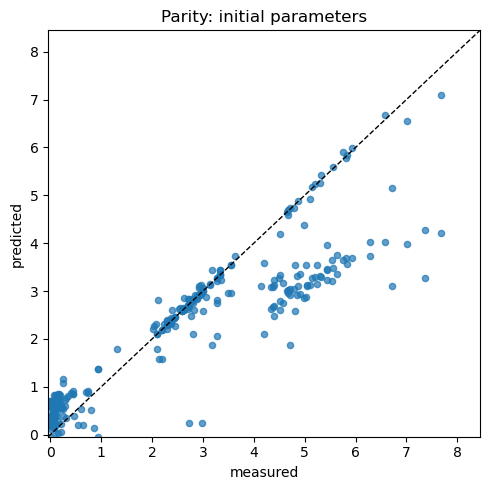

In [29]:
# Quick parity plot at initial parameters.
pv = pred0.predicted.to_numpy(dtype=float).ravel()
rv = pred0.real.to_numpy(dtype=float).ravel()
mask = ~(np.isnan(pv) | np.isnan(rv))
pv_m, rv_m = pv[mask], rv[mask]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(rv_m, pv_m, s=20, alpha=0.7)
lim_lo = min(rv_m.min(), pv_m.min()) * 0.9
lim_hi = max(rv_m.max(), pv_m.max()) * 1.1
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", lw=1)
ax.set_xlim(lim_lo, lim_hi); ax.set_ylim(lim_lo, lim_hi)
ax.set_xlabel("measured"); ax.set_ylabel("predicted")
ax.set_title("Parity: initial parameters")
fig.tight_layout()
# plt.savefig(os.path.join(RESULTS_DIR, "parity_init.png"), dpi=100, bbox_inches="tight")
plt.show()


## Parameter estimation



In [30]:
theta_fitted = None   # populated below if ipopt is available
obj_value = float("nan")

# The 37-param fit is rank-deficient (FIM rank ~10), so ipopt can satisfy
# tol=1e-6 only on the ~11 identifiable directions and oscillates on the rest,
# hitting max_iter.  Loosen the convergence target and add an "acceptable point"
# backstop so it terminates at a usable point with a status parmest accepts.
# NOTE: ~26 of the 37 params remain non-identifiable; their fitted values and
# confidence intervals are not meaningful (see the structural report).
est.solver_options = {
    "max_iter": 10000,
    "tol": 1e-8,

}
est.pest = est._make_estimator()
est.pest.tee = True

print("Running estimation with %d free parameters..." % len(est.free_params))
theta_series = est.estimate()
obj_value = est.obj_value
theta_fitted = {p: float(theta_series[p]) for p in theta_series.index}
print("Done. Objective value:", round(obj_value, 4))
print(pd.Series(theta_fitted).round(5).to_frame("theta_fitted").T.to_string())


Running estimation with 21 free parameters...
Ipopt 3.14.19: max_iter=10000
tol=1e-08


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:     2884
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:     3564

Total number of variables............................:      814
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      814
                     variables with only upper bounds:        0
Total

## Post-fit matrices and diagnostics

Each block below wraps its API call in try/except so that a single failure
(e.g. covariance not available without a successful fit) does not abort the
remaining cells.  Results are saved to RESULTS_DIR regardless.


In [13]:
qcov_df = None
corr_df = None
ci_df = None


cov_df = est.covariance()
corr_df = est.correlation_matrix()
ci_df = est.confidence_intervals(alpha=0.05)
print("Covariance shape:", cov_df.shape)
print("Correlation shape:", corr_df.shape)
print("Confidence intervals (head):")
print(ci_df.head().round(4).to_string())

Covariance shape: (20, 20)
Correlation shape: (20, 20)
Confidence intervals (head):
              theta   std_err     ci_low    ci_high  cv_percent
v_max_1   3190.5360  120.8063  2953.7557  3427.3162      3.7864
Ka1_1       42.2802    4.1939    34.0602    50.5002      9.9193
Ka2_1       35.0237    3.0168    29.1107    40.9367      8.6137
Ka3_1       49.1225   12.2290    25.1536    73.0914     24.8950
kcat_f_2  5039.0978  954.5028  3168.2723  6909.9234     18.9419


In [ ]:
cov_df

In [ ]:
theta_fitted

In [ ]:
fim_df = None


fim_df = est.fisher_information_matrix(theta=theta_init, free_only=True)
print("FIM shape:", fim_df.shape)
eigvals = np.sort(np.linalg.eigvalsh(fim_df.to_numpy(dtype=float)))[::-1]
print("FIM eigenvalues (top 10):", eigvals[:10].round(3))
print("FIM rank estimate (eigvals > 1e-10):",
        int(np.sum(eigvals > 1e-10)))


In [ ]:

_theta_for_sens = theta_fitted if theta_fitted is not None else theta_init
sens_dict = est.sensitivity_matrix(theta=_theta_for_sens, kind="both")
print("Sensitivity matrices computed for %d conditions." % len(sens_dict))
first_cond = next(iter(sens_dict))
print("  Shape for condition '%s':" % first_cond, sens_dict[first_cond].shape)


In [ ]:
pred_fitted = None
rmse_fitted = None


pred_fitted = est.predict(theta=theta_fitted)
rmse_fitted = pred_fitted.rmse
print("Post-fit prediction summary:")
print(pred_fitted.summary())


# RMSE comparison table.
rmse_tbl = pd.DataFrame({
    "init": pred0.rmse,
    "fitted": rmse_fitted,
})
print("\nRMSE comparison:")
print(rmse_tbl.round(4).to_string())
pv = pred_fitted.predicted.to_numpy(dtype=float).ravel()
rv = pred_fitted.real.to_numpy(dtype=float).ravel()
plt.scatter(pv, rv)

In [ ]:
# Per-reaction parameter comparison: initial vs fitted (one panel per reaction).
from kinetics_noor import PARAM_RXN_MAP

reactions = list(PARAM_RXN_MAP.keys())
has_fitted = theta_fitted is not None
width = 0.4

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, rxn in zip(axes.ravel(), reactions):
    params = PARAM_RXN_MAP[rxn]
    x = np.arange(len(params))
    init_vals = [theta_init[p] for p in params]

    ax.bar(x - width / 2, init_vals, width, label="init",
           color="steelblue", alpha=0.85)

    if has_fitted:
        fitted_vals = [theta_fitted[p] for p in params]
        ax.bar(x + width / 2, fitted_vals, width, label="fitted",
               color="tomato", alpha=0.85)

    ax.set_yscale("log")
    ax.set_title(rxn.upper())
    ax.set_xticks(x)
    ax.set_xticklabels(params, rotation=90, fontsize=7)
    ax.set_ylabel("value (log scale)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=10)

suptitle = "Parameter values by reaction: init vs fitted"
if not has_fitted:
    suptitle += "  (fitted unavailable -- showing init only)"

fig.suptitle(suptitle, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])

fig_dir = os.path.join(RESULTS_DIR, "figures")
os.makedirs(fig_dir, exist_ok=True)
fig.savefig(os.path.join(fig_dir, "theta_by_reaction.png"),
            dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
struct_report = None


_theta_for_struct = theta_fitted if theta_fitted is not None else theta_init
struct_report = est.structural_report(theta=_theta_for_struct, corr_threshold=0.9)
print("Structural report keys:", list(struct_report.keys()))
print("\nPer-condition:")
print(struct_report["per_condition"].round(2).to_string())
print("\nIdentifiability:")
print(struct_report["identifiability"].to_string())
print("\nPer-parameter (head):")
print(struct_report["per_parameter"].head(10).round(3).to_string())


## Save all artifacts to RESULTS_DIR


In [ ]:
def save_matrices(
    results_dir,
    theta_init,
    theta_sources_df,
    pred0,
    theta_fitted=None,
    pred_fitted=None,
    cov_df=None,
    corr_df=None,
    ci_df=None,
    fim_df=None,
    sens_dict=None,
    struct_report=None,
    obj_value=float("nan"),
    ipopt_available=False,
    seed=SEED,
    sigma_log10=SIGMA_LOG10,
    conditions=None,
    free_params=None,
):
    """
    Save all estimation artifacts to results_dir.
    Writes CSVs, JSON, pickle, and a manifest.
    """
    os.makedirs(results_dir, exist_ok=True)

    def _csv(df, name):
        if df is not None:
            df.to_csv(os.path.join(results_dir, name))
            print("  saved", name)

    # theta_init as a single-column CSV [value]
    ti_series = pd.Series(theta_init, name="value")
    ti_series.index.name = "param"
    _csv(ti_series.to_frame(), "theta_init.csv")

    # theta_init_sources: [param, value, source]
    _csv(theta_sources_df, "theta_init_sources.csv")

    # theta_fitted
    if theta_fitted is not None:
        tf_series = pd.Series(theta_fitted, name="value")
        tf_series.index.name = "param"
        _csv(tf_series.to_frame(), "theta_fitted.csv")

    # covariance / correlation / confidence intervals
    _csv(cov_df, "covariance.csv")
    _csv(corr_df, "correlation.csv")
    _csv(ci_df, "confidence_intervals.csv")
    _csv(fim_df, "fim.csv")

    # predictions
    if pred0 is not None:
        _csv(pred0.predicted, "predictions_init.csv")
        _csv(pred0.real, "real.csv")
        with open(os.path.join(results_dir, "rmse_init.json"), "w") as fh:
            json.dump({k: (None if not np.isfinite(v) else float(v))
                       for k, v in pred0.rmse.items()}, fh, indent=2)
        print("  saved rmse_init.json")

    if pred_fitted is not None:
        _csv(pred_fitted.predicted, "predictions_fitted.csv")
        with open(os.path.join(results_dir, "rmse_fitted.json"), "w") as fh:
            json.dump({k: (None if not np.isfinite(v) else float(v))
                       for k, v in pred_fitted.rmse.items()}, fh, indent=2)
        print("  saved rmse_fitted.json")

    # sensitivity matrices
    if sens_dict is not None:
        sens_path = os.path.join(results_dir, "sensitivity.pkl")
        with open(sens_path, "wb") as fh:
            pickle.dump(sens_dict, fh)
        print("  saved sensitivity.pkl (%d conditions)" % len(sens_dict))

        # also save per-condition CSVs for easy inspection
        sens_dir = os.path.join(results_dir, "sensitivity")
        os.makedirs(sens_dir, exist_ok=True)
        for cond, G_df in sens_dict.items():
            G_df.to_csv(os.path.join(sens_dir, "%s.csv" % cond))
        print("  saved sensitivity/ CSVs")

    # structural report
    if struct_report is not None:
        for key, df in struct_report.items():
            if isinstance(df, pd.DataFrame):
                fname = "structural_report_%s.csv" % key
                _csv(df, fname)

    # manifest
    manifest = {
        "seed": seed,
        "sigma_log10": sigma_log10,
        "conditions": conditions or [],
        "n_conditions": len(conditions) if conditions else 0,
        "n_measured": 14,
        "free_params": free_params or [],
        "n_free_params": len(free_params) if free_params else 0,
        "obj_value": None if not np.isfinite(obj_value) else float(obj_value),
        "ipopt_available": ipopt_available,
        "timestamp": datetime.datetime.utcnow().isoformat() + "Z",
    }
    with open(os.path.join(results_dir, "manifest.json"), "w") as fh:
        json.dump(manifest, fh, indent=2)
    print("  saved manifest.json")
    print("All artifacts saved to:", results_dir)


save_matrices(
    results_dir=RESULTS_DIR,
    theta_init=theta_init,
    theta_sources_df=theta_sources_df,
    pred0=pred0,
    theta_fitted=theta_fitted,
    pred_fitted=pred_fitted,
    cov_df=cov_df,
    corr_df=corr_df,
    ci_df=ci_df,
    fim_df=fim_df,
    sens_dict=sens_dict,
    struct_report=struct_report,
    obj_value=obj_value,
    seed=SEED,
    sigma_log10=SIGMA_LOG10,
    conditions=CONDITIONS,
    free_params=list(ALL_PARAMS),
)

In [ ]:
# Comparable sensitivity footing (shared with fixed_estimation)
# Overwrite the per-condition sensitivity CSVs and predictions_fitted.csv at the
# fitted theta using the SAME data-derived bounds + sorted conditions as
# fixed_estimation, so the two sensitivity heatmaps differ ONLY by theta. The
# parmest posterior covariance / CIs / fix-justification above are unaffected.
if theta_fitted is not None:
    from utils import build_analysis_model, save_per_condition_sensitivity

    _amodel, _aconds, _aenz, _aneed, _ameas = build_analysis_model('Data', n_std=N_STD)
    _pred_cmp, _real_cmp = save_per_condition_sensitivity(
        _amodel, theta_fitted, _aconds, _aenz, _aneed, RESULTS_DIR, data_dir='Data')
    _pred_cmp.to_csv(os.path.join(RESULTS_DIR, 'predictions_fitted.csv'))
    print('Regenerated comparable sensitivity/ + predictions_fitted.csv at theta_fitted')
    print('  (data-derived bounds, %d sorted conditions).' % len(_aconds))
else:
    print('No theta_fitted (ipopt unavailable) -- comparable-footing step skipped.')
